# Lesson 11 activity: data visualization

In this activity, you'll use matplotlib, seaborn, and plotly to explore a housing sales dataset through a series of plots.

## Problem statement:
Analyze the housing dataset using various types of plots to gain insights into the data.

Housing sales dataset available here: [housing_data.csv](https://raw.githubusercontent.com/gperdrizet/fullstack-2605/main/data/housing_data.csv)

## Steps to complete:
1. Create a line plot to visualize the trend of house prices over the years.
2. Use a scatter plot to visualize the relationship between `LotArea` and `SalePrice`.
3. Create a bar chart to show the count of houses in each `Neighborhood`.
4. Use a box plot to visualize the distribution of `SalePrice` in each `Neighborhood`.
5. Create a pie chart to visualize the proportion of houses in each `MSZoning` category.
6. Use a 3D scatter plot to visualize `LotArea`, `OverallQual`, and `SalePrice` together.

In [22]:
import pandas as pd

lfs_url = 'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/housing_data.csv'
alt_url = 'https://github.com/gperdrizet/fullstack-2605/raw/main/data/housing_data.csv'

try:
    df = pd.read_csv(lfs_url)
except Exception as e:
    print(f'Primary URL failed: {type(e).__name__}: {e}')
    print('Trying fallback...')
    df = pd.read_csv(alt_url)

print(df.shape)
df.head()
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns

thousands = FuncFormatter(lambda x, _: f'{x/1000:,.0f}')

(1460, 81)


## Load the dataset

In [23]:
url = 'https://media.githubusercontent.com/media/gperdrizet/fullstack-2605/refs/heads/main/data/housing_data.csv'
df = pd.read_csv(url)
df.head()

,Unnamed: 0,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,0,SC60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,Feb,2008,WD,Normal,208500
1,1,SC20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,No,No,No,0,May,2007,WD,Normal,181500
2,2,SC60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Sep,2008,WD,Normal,223500
3,3,SC70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Feb,2006,WD,Abnorml,140000
4,4,SC60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,No,No,No,0,Dec,2008,WD,Normal,250000


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     1460 non-null   int64  
 1   MSSubClass     1460 non-null   object 
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

## 1. House price trends over time

Create a line plot showing how mean sale price changed each year. Include error bars showing the standard deviation.

**Hints:**
- Convert `YrSold` to string so it's treated as a categorical axis
- Use `groupby` to calculate mean and standard deviation per year
- `plt.errorbar()` can draw the error bars; `plt.plot()` draws the line
- Use `FuncFormatter` to scale the y-axis to thousands

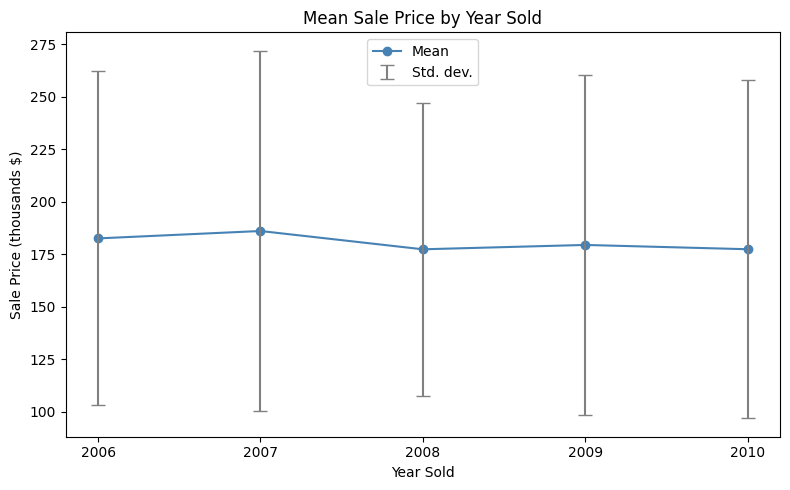

In [25]:
# Convert sale year to string so it's treated as a categorical variable
df['YrSold'] = df['YrSold'].astype(str)

# Group by year and calculate mean and standard deviation of sale price
yearly = df.groupby('YrSold')['SalePrice'].agg(['mean', 'std'])

# Create a line plot with error bars
plt.figure(figsize=(8, 5))
plt.plot(yearly.index, yearly['mean'], marker='o', color='steelblue', label='Mean')
plt.errorbar(
    yearly.index, yearly['mean'], yerr=yearly['std'],
    fmt='none', ecolor='gray', capsize=5, label='Std. dev.'
)

plt.title('Mean Sale Price by Year Sold')
plt.xlabel('Year Sold')
plt.ylabel('Sale Price (thousands $)')
plt.gca().yaxis.set_major_formatter(thousands)
plt.legend()
plt.tight_layout()
plt.show()

## 2. LotArea vs SalePrice

Create a scatter plot showing the relationship between lot area and sale price.

**Hints:**
- Use `plt.scatter()` or `sns.scatterplot()`
- The data has outliers — experiment with axis limits or log scale to make the relationship clearer
- Use `FuncFormatter` to scale both axes to thousands

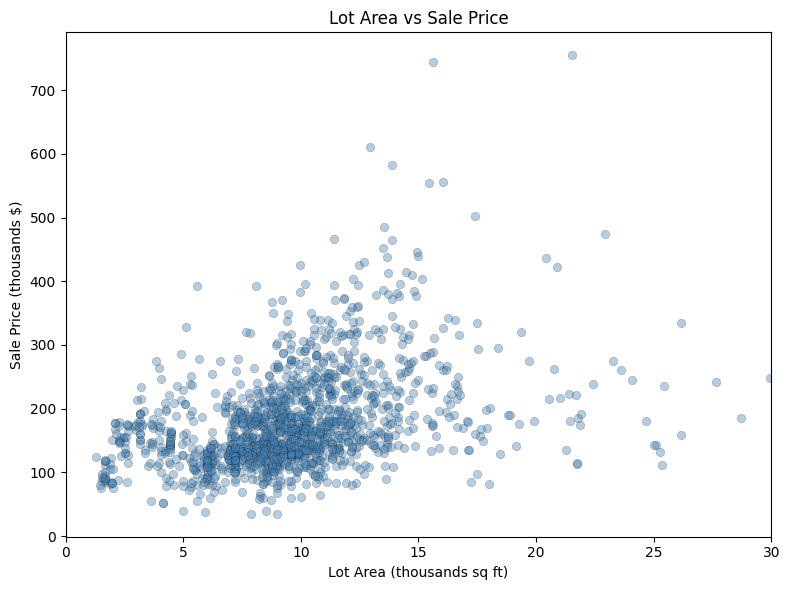

In [31]:
# Create a scatter plot of LotArea vs SalePrice
plt.figure(figsize=(8, 6))
plt.scatter(df['LotArea'], df['SalePrice'],
            alpha=0.4, edgecolor='black', linewidth=0.3, color='steelblue')

# Clip the extreme lot-area outliers so the cluster is visible
plt.xlim(0, 30000)

# Alternative approach to outliers: log scale on both axes
# plt.xscale('log'); plt.yscale('log')

plt.title('Lot Area vs Sale Price')
plt.xlabel('Lot Area (thousands sq ft)')
plt.ylabel('Sale Price (thousands $)')
plt.gca().xaxis.set_major_formatter(thousands)
plt.gca().yaxis.set_major_formatter(thousands)
plt.tight_layout()
plt.show()

plt.show()

## 3. House count by neighborhood

Create a bar chart showing how many houses are in each neighborhood.

**Hints:**
- Use `value_counts()` to count houses per neighborhood
- A horizontal bar chart (`plt.barh()` or `sns.barplot()`) works well here since neighborhood names are long
- Sort the bars by count to make the chart easier to read

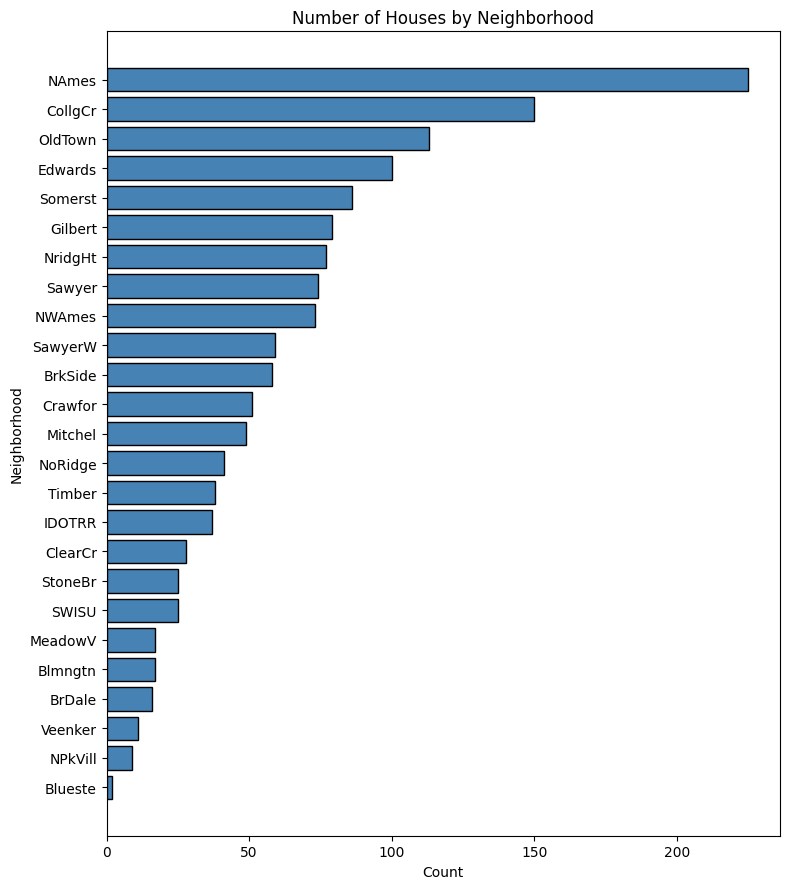

In [32]:
# Count houses by neighborhood
# Count houses by neighborhood (ascending so the longest bar lands on top in barh)
counts = df['Neighborhood'].value_counts().sort_values()

# Create a bar chart
plt.figure(figsize=(8, 9))
plt.barh(counts.index, counts.values, color='steelblue', edgecolor='black')
plt.title('Number of Houses by Neighborhood')
plt.xlabel('Count')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

# Create a bar chart
# Your code here

plt.show()

## 4. SalePrice distribution by neighborhood

Create a box plot showing the distribution of sale prices in each neighborhood.

**Hints:**
- Use `sns.boxplot()` with `x='Neighborhood'` and `y='SalePrice'`
- Order neighborhoods by median sale price using `groupby` + `sort_values`
- Rotate x-axis labels so they don't overlap (`plt.xticks(rotation=45, ha='right')`)
- Use `FuncFormatter` to scale the y-axis to thousands

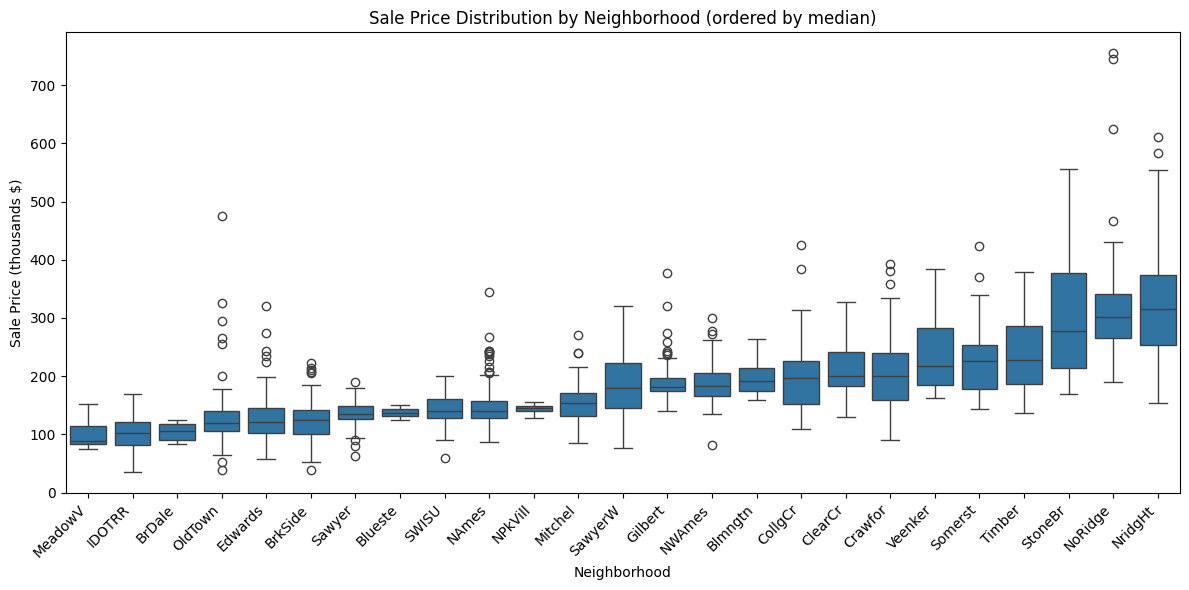

In [33]:
# Get list of neighborhoods ordered by median sale price
# Get list of neighborhoods ordered by median sale price
order = (
    df.groupby('Neighborhood')['SalePrice']
      .median()
      .sort_values()
      .index
)

# Create a box plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice', order=order)
plt.title('Sale Price Distribution by Neighborhood (ordered by median)')
plt.xlabel('Neighborhood')
plt.ylabel('Sale Price (thousands $)')
plt.xticks(rotation=45, ha='right')
plt.gca().yaxis.set_major_formatter(thousands)
plt.tight_layout()
plt.show()

# Create a box plot
# Your code here

plt.show()

## 5. Proportion of houses by MSZoning

Create a pie chart showing what proportion of houses fall into each zoning category.

**Hints:**
- Use `value_counts()` to count houses per zoning category
- Use `plt.pie()` with a legend showing category labels and percentages
- Calculate percentages as `counts / counts.sum() * 100`

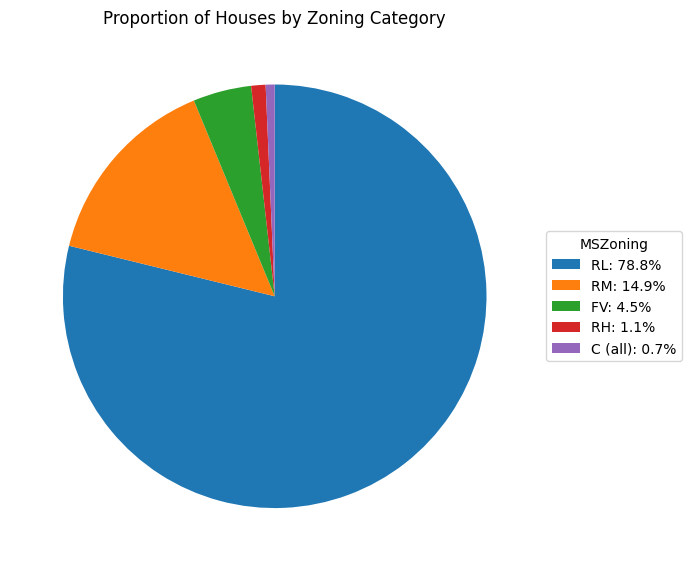

In [34]:
# Count houses by MSZoning
# Count houses by MSZoning
counts = df['MSZoning'].value_counts()
percentages = counts / counts.sum() * 100

# Create a pie chart
plt.figure(figsize=(7, 7))
wedges, _ = plt.pie(counts, startangle=90, counterclock=False)

labels = [f'{cat}: {pct:.1f}%' for cat, pct in zip(counts.index, percentages)]
plt.legend(wedges, labels, title='MSZoning',
           loc='center left', bbox_to_anchor=(1.0, 0.5))
plt.title('Proportion of Houses by Zoning Category')
plt.tight_layout()
plt.show()

# Create a pie chart
# Your code here

plt.show()

## 6. 3D scatter plot: LotArea, OverallQual, and SalePrice

Create a 3D scatter plot with `LotArea` on the x-axis, `OverallQual` on the y-axis, and `SalePrice` on the z-axis. Color the points by sale price.

**Hints:**
- For matplotlib: use `plt.axes(projection='3d')` then `ax.scatter()`
- For plotly: use `px.scatter_3d()` for an interactive version
- Use `FuncFormatter` to scale the lot area and sale price axes to thousands
- Use `cmap='viridis'` and add a colorbar

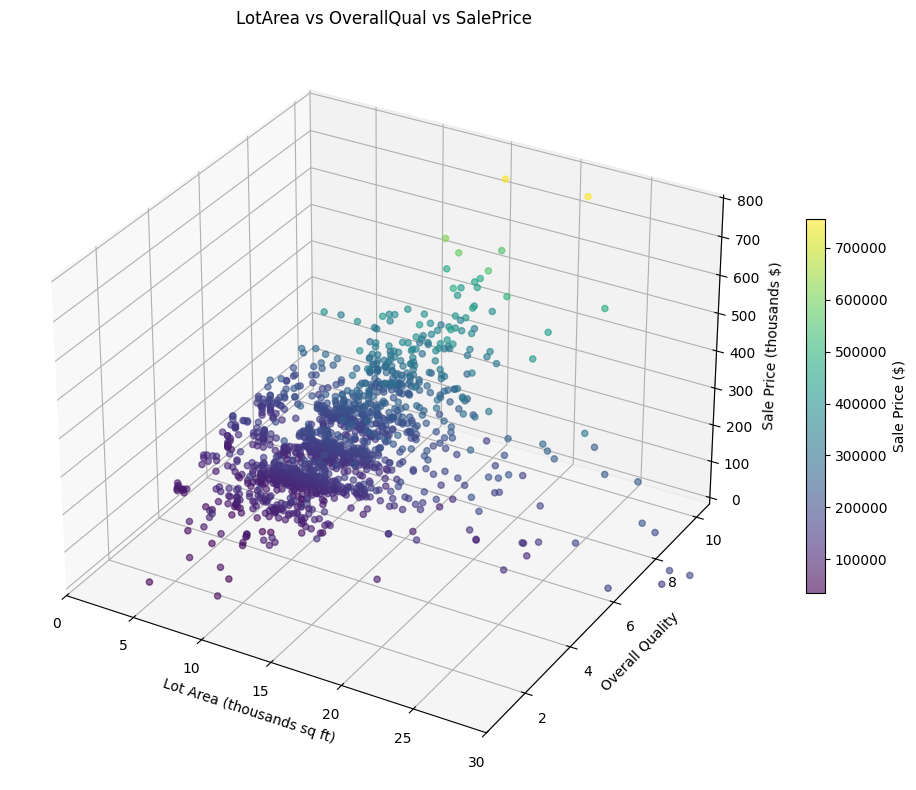

In [36]:
# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = plt.axes(projection='3d')

p = ax.scatter(
    df['LotArea'], df['OverallQual'], df['SalePrice'],
    c=df['SalePrice'], cmap='viridis', alpha=0.6
)

ax.set_xlim(0, 30000)  # tame the lot-area outliers again
ax.set_xlabel('Lot Area (thousands sq ft)')
ax.set_ylabel('Overall Quality')
ax.set_zlabel('Sale Price (thousands $)')
ax.xaxis.set_major_formatter(thousands)
ax.zaxis.set_major_formatter(thousands)

fig.colorbar(p, ax=ax, shrink=0.5, label='Sale Price ($)')
plt.title('LotArea vs OverallQual vs SalePrice')
plt.tight_layout()
plt.show()

plt.show()

import plotly.express as px

fig = px.scatter_3d(
    df, x='LotArea', y='OverallQual', z='SalePrice',
    color='SalePrice', color_continuous_scale='viridis', opacity=0.7,
    title='LotArea vs OverallQual vs SalePrice (interactive)'
)
fig.update_traces(marker=dict(size=3))
fig.show()